### Default LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v


=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.813919  0.780890    0.155422  0.170015   0.117971  0.130146
1     2  0.814396  0.771676    0.155418  0.172671   0.117624  0.132289
2     3  0.814906  0.779041    0.154874  0.171312   0.117831  0.129014
3     4  0.819074  0.757042    0.154426  0.173546   0.117119  0.131687
4     5  0.812289  0.783219    0.156119  0.169047   0.118445  0.129878

LIGHTGBM (DEFAULT) - 5-FOLD CV (LOG SCALE)
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8149         0.7744         0.0405
RMSE               0.1553         0.1713               
MAE                0.1178         0.1306               

LIGHTGBM (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)
Metric              Train           Test
----------------------------------------------------------------------
R²                 0.8062         0.768

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

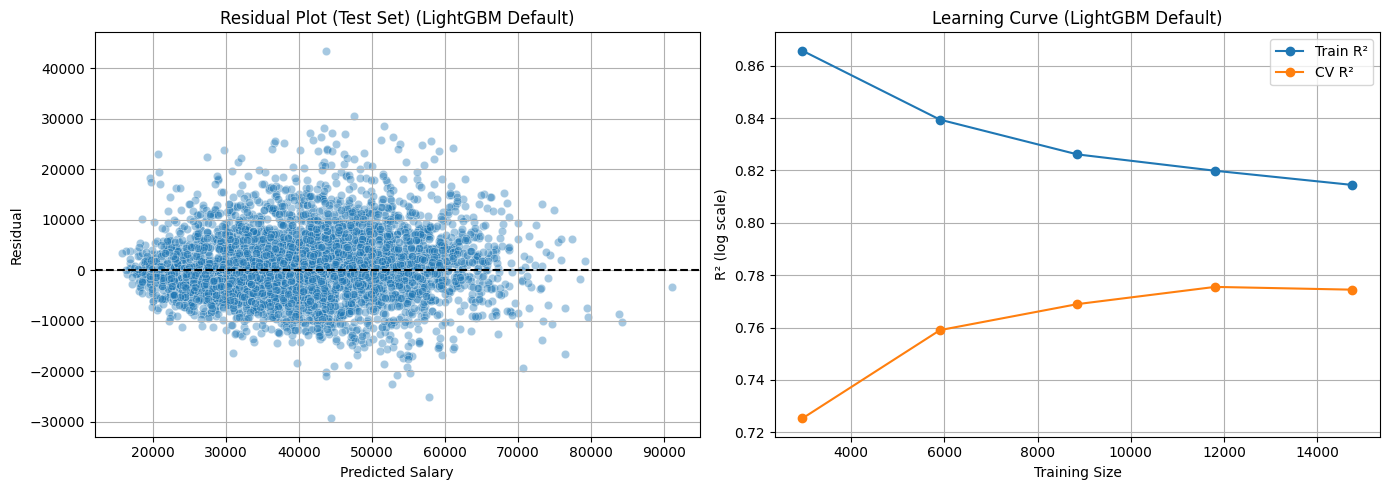

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Machine Learning Models
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

warnings.filterwarnings("ignore")

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]
y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", lgb.LGBMRegressor(
        random_state=seed,
        n_jobs=-1,
        verbose=-1
    ))
])

# CROSS VALIDATION SETUP
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

# RUN CROSS VALIDATION
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'LIGHTGBM (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
model.fit(X_train, y_train)

# Predictions (LOG SCALE)
train_pred_log = model.predict(X_train)
test_pred_log  = model.predict(X_test)

# INVERSE TRANSFORM (BACK TO ORIGINAL SALARY)
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'LIGHTGBM (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot (ORIGINAL SCALE) ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (LightGBM Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve (LOG SCALE) ---
train_sizes, train_scores, val_scores = learning_curve(
    model,                 
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    marker='o',
    label="Train R²"
)

axes[1].plot(
    train_sizes,
    np.mean(val_scores, axis=1),
    marker='o',
    label="CV R²"
)

axes[1].grid(True)
axes[1].set_title("Learning Curve (LightGBM Default)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hyperparameter-tuned LightGBM

[I 2026-05-06 02:04:01,892] A new study created in memory with name: no-name-9a03df1e-aa3e-4ace-a37e-7316f49f2cf1
[I 2026-05-06 02:04:27,120] Trial 0 finished with value: 0.7968563993237521 and parameters: {'n_estimators': 923, 'learning_rate': 0.04597738803995444, 'num_leaves': 75, 'min_child_samples': 54, 'reg_alpha': 0.46775134166620363, 'reg_lambda': 5.978260439815658}. Best is trial 0 with value: 0.7968563993237521.
[I 2026-05-06 02:04:52,628] Trial 1 finished with value: 0.7992306382831714 and parameters: {'n_estimators': 977, 'learning_rate': 0.04522446379193156, 'num_leaves': 60, 'min_child_samples': 48, 'reg_alpha': 0.5243770950041713, 'reg_lambda': 5.319497102446249}. Best is trial 1 with value: 0.7992306382831714.
[I 2026-05-06 02:05:19,487] Trial 2 finished with value: 0.7954525163544469 and parameters: {'n_estimators': 916, 'learning_rate': 0.03275538503886134, 'num_leaves': 74, 'min_child_samples': 48, 'reg_alpha': 0.5536753453541974, 'reg_lambda': 6.026825462733941}. Bes


 BEST OPTUNA PARAMETERS
n_estimators: 1083
learning_rate: 0.05432604574401225
num_leaves: 60
min_child_samples: 45
reg_alpha: 0.41090869382369954
reg_lambda: 5.936745834288808

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.868008  0.809377    0.130899  0.158578   0.095736  0.117854
1     2  0.872595  0.804396    0.128766  0.159820   0.094054  0.118286
2     3  0.871534  0.804148    0.129026  0.161285   0.094512  0.118521
3     4  0.875517  0.784734    0.128093  0.163357   0.093341  0.120586
4     5  0.868154  0.813994    0.130841  0.156589   0.095417  0.116913

               LIGHTGBM (TUNED) - 5-FOLD CV (LOG SCALE)               
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8712         0.8033         0.0678
RMSE               0.1295         0.1599               
MAE                0.0946         0.1184              

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

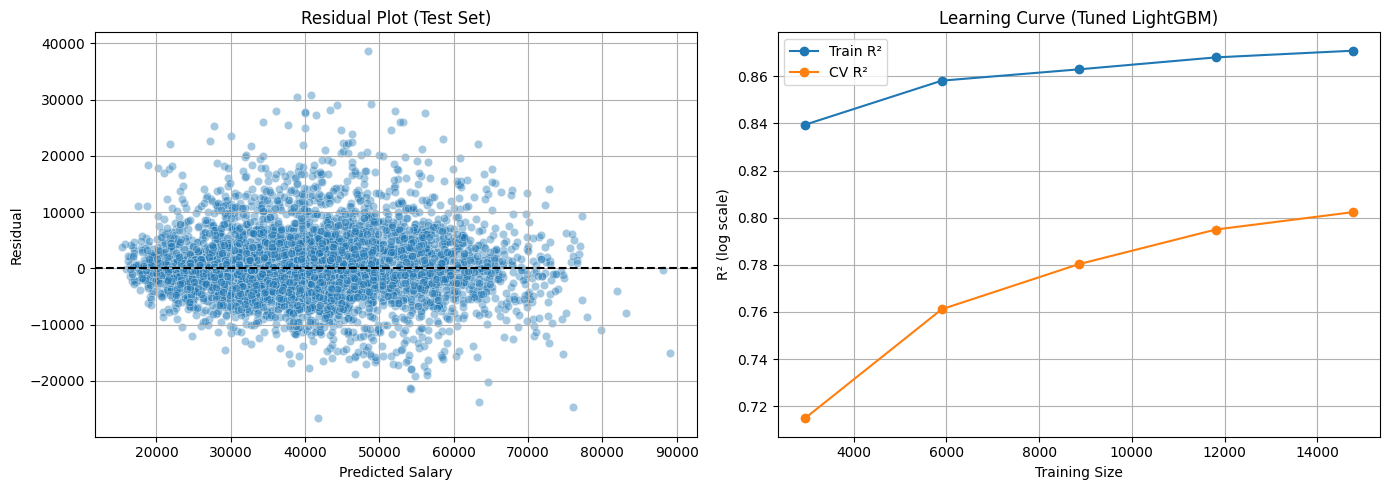

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import lightgbm as lgb

warnings.filterwarnings("ignore")

# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]
y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# TFIDF CONFIG
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

cv = KFold(n_splits=5, shuffle=True, random_state=seed)

# OPTUNA OBJECTIVE
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 900, 1100),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.055, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 60, 75),
        "min_child_samples": trial.suggest_int("min_child_samples", 45, 55),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.4, 0.6),
        "reg_lambda": trial.suggest_float("reg_lambda", 5.0, 7.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }

    model = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_config)),
        ("lgbm", lgb.LGBMRegressor(**params))
    ])

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        return_train_score=True,
        n_jobs=1
    )

    score = np.mean(cv_results["test_score"])

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

best_params = study.best_params

# PRINT BEST PARAMETERS FIRST
print("\n" + "="*80)
print(" BEST OPTUNA PARAMETERS")
print("="*80)
for k, v in best_params.items():
    print(f"{k}: {v}")
print("="*80)

# BEST MODEL
best_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("lgbm", lgb.LGBMRegressor(**best_params, random_state=seed, n_jobs=-1, verbose=-1))
])

# CROSS VALIDATION (MATCH BASELINE FORMAT)
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True,
    n_jobs=1
)


# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT (SAME FORMAT AS BASELINES)
print("\n" + "="*70)
print(f"{'LIGHTGBM (TUNED) - 5-FOLD CV (LOG SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# FINAL TRAIN
best_model.fit(X_train, y_train)

train_pred_log = best_model.predict(X_train)
test_pred_log  = best_model.predict(X_test)

# inverse transform
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

# TEST METRICS (REAL SCALE)
test_r2 = r2_score(y_test_real, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_real, test_pred))
test_mae = mean_absolute_error(y_test_real, test_pred)

train_r2_real = r2_score(y_train_real, train_pred)
train_rmse_real = np.sqrt(mean_squared_error(y_train_real, train_pred))
train_mae_real = mean_absolute_error(y_train_real, train_pred)

# PRINT TEST RESULTS (SAME STYLE AS BASELINE)
print("\n" + "="*70)
print(f"{'LIGHTGBM (TUNED) - TRAIN & TEST (ORIGINAL SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_real:>15.4f}{test_r2:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_real:>15,.2f}{test_rmse:>15,.2f}")
print(f"{'MAE':<10}{train_mae_real:>15,.2f}{test_mae:>15,.2f}")
print("="*70)


# PLOTS 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test_real - test_pred

sns.scatterplot(x=test_pred, y=residuals, alpha=0.4, ax=axes[0])
axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(train_sizes, np.mean(train_scores, axis=1), marker='o', label="Train R²")
axes[1].plot(train_sizes, np.mean(val_scores, axis=1), marker='o', label="CV R²")

axes[1].grid(True)
axes[1].set_title("Learning Curve (Tuned LightGBM)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()